# k-Nearest Neighbors (kNN)
* **obiettivo**: classificare (ossia etichettare) un punto $x$, in base all'etichetta che compare di piu nei $k$ punti piu' vicini.

* **classificare**: punto $x$ in base alle etichette dei $k$ punti piu' vicini nel dataset etichettato.

* **apprendimento**: consiste nel memorizzare il **dataset di apprendimento**

# Codifica
* **fitting**: consiste nella memorizzazione.

* **predict**: consiste nella ricerca dei `k`  vicini.

* **costo del predict**: lineare nel dataset di apprendimento, assumendo $k$ costante.


In [40]:
import numpy as np  # libreria per calcolo vettoriale... ma non solo
import matplotlib.pyplot as plt  # librerie per il disegno
import matplotlib.patches as patches

# creare array
center = np.array([0,0])
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1], [1.01, -0.9, 1],
                   [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0], [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]])

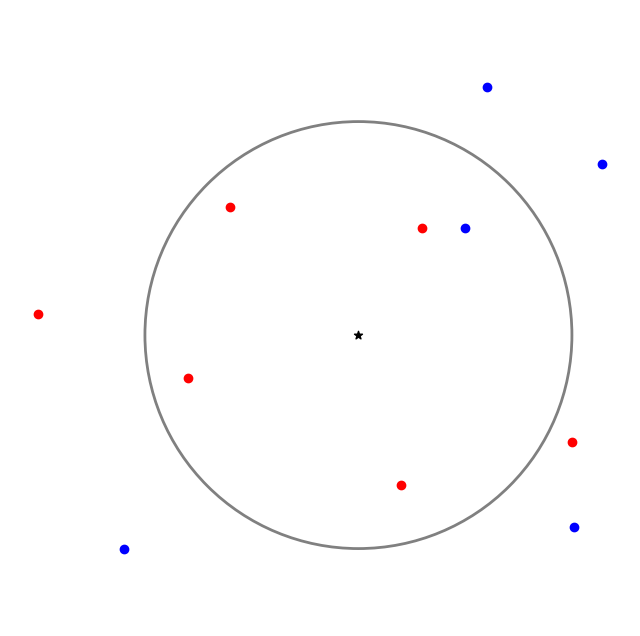

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))   # nuova figura di dimensione 8x8

ax.scatter(center[0], center[1], color='black', marker='*')   # disegno del punto al centro come una stella
circle = patches.Circle(center, 1, edgecolor='gray', facecolor= None, alpha=1, linewidth=2, fill=False)   # definisce cerchio centrato in center

# disegna i punti con etichetta 1 definendo la lista delle coordinate x e y usando
# list comprehension (vedere)
ax.scatter([x for x,y,t in points if t == 1], [y for x,y,t in points if t == 1], color = 'blue', marker='o')
# stessa cosa con etichetta 0
ax.scatter([x for x,y,t in points if t == 0], [y for x,y,t in points if t == 0], color = 'red', marker='o')

# aggiunge cenchio al disegno
ax.add_patch(circle)
ax.axis('equal')
ax.axis('off')

# salve disegno
plt.savefig('01-28-knn.png', dpi=120, bbox_inches='tight')

plt.show()


In [42]:
def euclidean_dist(a0,a1):
    return np.linalg.norm(a0-a1)

def selection_sort(a, x, k=None, key=None):
    # x: oggetto da classificare
    # k: numero di indici da ritornare
    # key: funzione di distanza tra due oggetti x e y

    if k == None or k > len(a) or k < 0:
        k=len(a)
    if key == None:
        key = lambda y, _: y

    idxs = [] # idxs[:i] le posizioni dei primi elementi di a in ordine di grandezza
    for i in range(k):
        # il migliore indice trovato
        m = None
        for j,v in enumerate(a):
            if m == None or key(v,x) < key(a[m],x):
                if j not in idxs: 
                    m=j
        idxs.append(m)
    return idxs

# mode = moda, ossia l'elemento piu' frequente
def mode(a):
    # ritorna a senza ripetizioni (elementi unici) + una lista dei conteggi per ogni elemento
    itms, cnts = np.unique(np.array(a), return_counts=True)
    # argmax: trova l'indice che massimizza il valore in cnts
    # max: trova il valore massimo
    return itms[np.argmax(cnts)], max(cnts)

class KNN(object):
    def __init__(self, k = 5, distance = None):
        self.k = k
        if distance == None:
            self._dist = euclidean_dist
        else:
            self._dist = distance
    
    def fit(self, X, y):
        self.X = X  # X è una matrice n x d (n campioni, d features)
        self.y = y  # y è un array di dimensione n
        
    def predict(self, x):        
        # Ottiene gli indici dei k punti più vicini
        k_indices = selection_sort(self.X, x, k=5, key = self._dist)
        
        # Prende le etichette corrispondenti
        return mode(self.y[k_indices])


# complessita
**efficiente**: se $k$ piccolo allora richiede $\Theta(k n)$ operazioni

**kd tree**: permette di scendere a $\Theta(k log n)$

**costruzione kd tree**: $\Theta(k log^2n)$

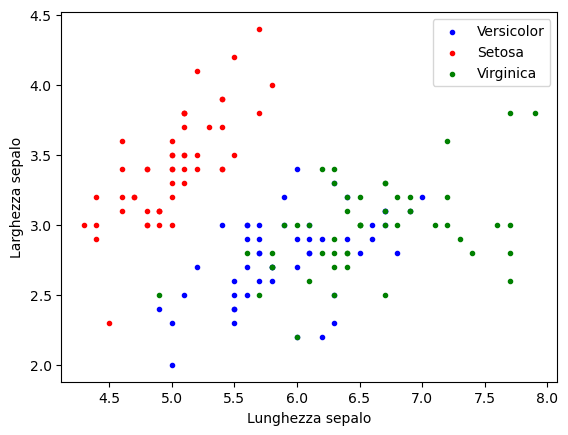

In [43]:
import os
import pandas as pd
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s, header=None, encoding='utf-8')

# iloc: e' il dataframe indicizzabile usando gli interi
# X valori del dataset
X = df.iloc[:, [0,1]].values
# etichette
y = df.iloc[:,4].values

versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]

# ATTENZIONE: devo scegliere un sott'insieme di features ottimale
# da usare come training set per la classificazione.
X = df.iloc[:, [0,1]].values
y = df.iloc[:, 4].values

plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Lunghezza sepalo')
plt.ylabel('Larghezza sepalo')
plt.legend()

plt.savefig('01-24-iris_01.png', dpi=120, bbox_inches='tight')


# classificazione e testing
**scegliere le features**: nel codice sopra visualizziamo i punti nel grafo e gli diamo un'etichetta.

**punti**: hanno due cordinate, e possiamo scegliere un sottoinsieme a nostro piacimento rispetto alle features di ogni iris per posizionare i punti nel grafo.

**obiettivo**: identificare la combinazione di features che divide meglio le etichette.

**training set**: addestrare il classificatore, in kNN il training set non serve ad addestrare, dato che non devo addestrare un cazzo di nulla

**test set**: viene usato per testare il classificatore, confrontando i risultati del classificatore con i dati reali.

**train_test_split**: dato un dataset in input voglio dividerlo in train e test.



In [44]:
def train_test_split(X, y, train_size = 0.7):
    n = X.shape[0]
    train_idxs = np.random.choice(n, size = int(n*train_size), replace=False)
    test_idxs =  np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]

X = df.iloc[:, :-1].values  # i valori in tutte le righe e tutte le colonne tranne l'ultima
y = df.iloc[:, 4].values # i valori nell'ultima colonna
#y = df.iloc[:, -1].values # alteternativa alla precedente

X_train, y_train, X_test, y_test = train_test_split(X, y)

In [45]:
knn = KNN()
# memorizza il dataset per addestrare 
knn.fit(X_train, y_train)
for x, t in zip(X_test[:10], y_test[:10]):
    print(x,t, knn.predict(x))

[4.7 3.2 1.3 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.6 3.4 1.4 0.3] Iris-setosa ('Iris-setosa', np.int64(5))
[4.4 2.9 1.4 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.7 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.8 3.  1.4 0.1] Iris-setosa ('Iris-setosa', np.int64(5))
[5.7 3.8 1.7 0.3] Iris-setosa ('Iris-setosa', np.int64(5))
[5.1 3.3 1.7 0.5] Iris-setosa ('Iris-setosa', np.int64(5))
[4.8 3.4 1.9 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.  1.6 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.4 1.6 0.4] Iris-setosa ('Iris-setosa', np.int64(5))


# Esercizi
1. `train_test_split` dovrebbe avere ritornare dataset in output con stessa distribuzione delle etichette in input

In [ ]:
def train_test_split(X, y, train_size = 0.7):

    train_idxs = []
    for l in ["Iris-setosa", "Iris-virginica", "Iris-veriscolor"]:
        X_filtered = X[np.where(y == l)]
        n = X_filtered.shape[0]
        X_train = X_filtered[np.random.choice(n, size=n.train_size, replace=False)]
        train_idxs.append(X_train)

    n = X.shape[0]
    train_idxs = np.random.choice(n, size = int(n*train_size), replace=False)
    test_idxs =  np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]


train_test_split(X,y)

TypeError: expected a sequence of integers or a single integer, got '35.0'